<a href="https://colab.research.google.com/github/woalsse/KOSPI-VaR-Backtesting-Project/blob/main/03_Parametric_VaR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q yfinance --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 1.0 MB/s eta 0:00:00


Ticker      : ^KS11
Period      : 2019-01-03 ~ 2026-07-30
Observations: 1,857

Descriptive Statistics
  Mean (daily)    : 0.000551
  Std dev (daily) : 0.016031
  Annualized vol  : 0.2545
  Skewness        : -0.8887
  Excess kurtosis : 10.7223
  Minimum         : -0.1285 (2026-03-04)
  Maximum         : 0.0919 (2026-03-05)

Jarque-Bera Normality Test
  Statistic : 9086.58
  p-value   : 0
  Result    : Reject H0 at 5% level

Worst daily return         : -8.05 sigma
Probability under normality: 4.154e-16


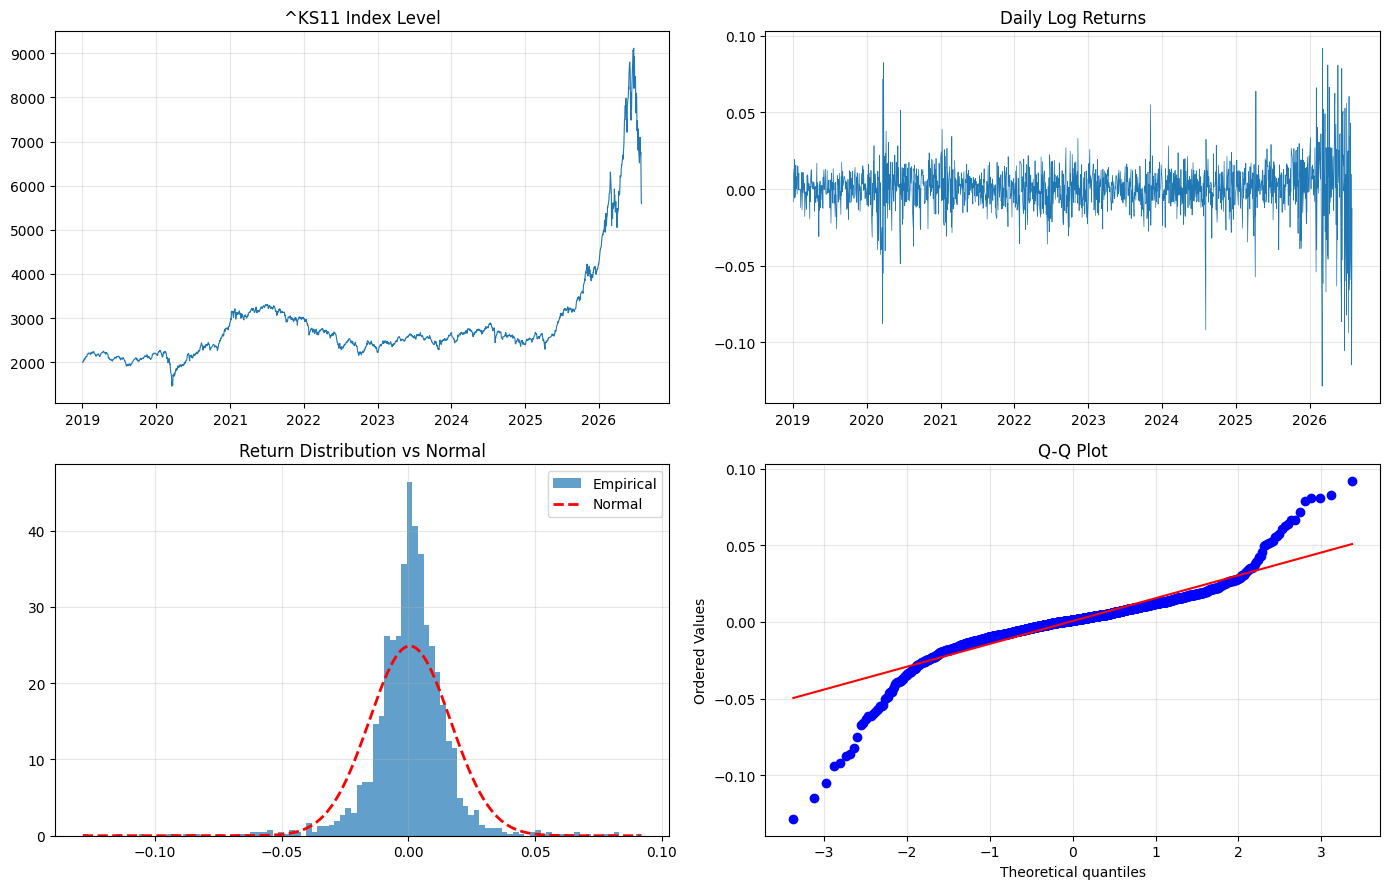

In [2]:
"""KOSPI 일별 로그수익률의 기초통계량 및 정규성 진단."""

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf


TICKER = "^KS11"
START_DATE = "2019-01-01"
END_DATE = "2026-07-31"
TRADING_DAYS = 252

FIGURE_DIR = "figures"
DATA_DIR = "data"


def load_prices(ticker, start, end):
    """Yahoo Finance에서 수정종가를 받아온다.

    KRX 정보데이터시스템이 회원제로 전환되면서 pykrx는 로그인 정보를
    요구하게 되어, 인증이 필요 없는 Yahoo Finance로 대체했다.
    """
    raw = yf.download(ticker, start=start, end=end,
                      auto_adjust=True, progress=False)

    if raw is None or len(raw) == 0:
        raise SystemExit(f"데이터 수집 실패: {ticker}")

    # 최근 버전의 yfinance는 단일 티커 요청에도 2단 컬럼을 반환하므로
    # 1단으로 평탄화한다.
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    return pd.DataFrame({"close": raw["Close"]}).dropna()


def compute_log_returns(prices):
    """로그수익률을 계산한다. 보유기간 간 가법성 때문에 단순수익률 대신 사용."""
    df = prices.copy()
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    return df.dropna()


def summarize(returns):
    print(f"Ticker      : {TICKER}")
    print(f"Period      : {returns.index[0].date()} ~ {returns.index[-1].date()}")
    print(f"Observations: {len(returns):,}")
    print()

    print("Descriptive Statistics")
    print(f"  Mean (daily)    : {returns.mean():.6f}")
    print(f"  Std dev (daily) : {returns.std():.6f}")
    print(f"  Annualized vol  : {returns.std() * np.sqrt(TRADING_DAYS):.4f}")
    print(f"  Skewness        : {returns.skew():.4f}")
    # pandas는 초과첨도를 반환한다. 정규분포 기준값은 3이 아니라 0.
    print(f"  Excess kurtosis : {returns.kurtosis():.4f}")
    print(f"  Minimum         : {returns.min():.4f} ({returns.idxmin().date()})")
    print(f"  Maximum         : {returns.max():.4f} ({returns.idxmax().date()})")
    print()

    jb_stat, jb_pvalue = stats.jarque_bera(returns)
    print("Jarque-Bera Normality Test")
    print(f"  Statistic : {jb_stat:.2f}")
    print(f"  p-value   : {jb_pvalue:.6g}")
    print(f"  Result    : {'Reject H0' if jb_pvalue < 0.05 else 'Fail to reject H0'} at 5% level")
    print()

    # 최대 손실일을 표준편차 단위로 환산해, 정규분포 가정 하에서
    # 해당 사건이 얼마나 비현실적인지를 수치로 보인다.
    z_min = (returns.min() - returns.mean()) / returns.std()
    print(f"Worst daily return         : {z_min:.2f} sigma")
    print(f"Probability under normality: {stats.norm.cdf(z_min):.3e}")


def plot_diagnostics(df, returns, path):
    # 그래프 라벨은 한글 폰트 문제를 피하기 위해 영문으로 유지한다.
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(df.index, df["close"], linewidth=0.8)
    axes[0, 0].set_title(f"{TICKER} Index Level")
    axes[0, 0].grid(alpha=0.3)

    # 변동성 군집이 있다면 안정 구간과 급변 구간이 교대로 나타난다.
    axes[0, 1].plot(df.index, returns, linewidth=0.5)
    axes[0, 1].set_title("Daily Log Returns")
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(returns, bins=100, density=True, alpha=0.7, label="Empirical")
    x = np.linspace(returns.min(), returns.max(), 300)
    axes[1, 0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
                    "r--", linewidth=2, label="Normal")
    axes[1, 0].set_title("Return Distribution vs Normal")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    stats.probplot(returns, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("Q-Q Plot")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()


def main():
    os.makedirs(FIGURE_DIR, exist_ok=True)
    os.makedirs(DATA_DIR, exist_ok=True)

    prices = load_prices(TICKER, START_DATE, END_DATE)
    df = compute_log_returns(prices)
    returns = df["log_return"]

    summarize(returns)
    plot_diagnostics(df, returns, os.path.join(FIGURE_DIR, "day1_returns_analysis.png"))

    # 2주차 VaR 계산에서 이 파일을 그대로 불러 쓴다.
    df.to_csv(os.path.join(DATA_DIR, "kospi_returns.csv"), encoding="utf-8-sig")


if __name__ == "__main__":
    main()

Historical Simulation VaR
  Window          : 250 days
  Confidence      : 99%
  Testable days   : 1,607

  Violations      : 39
  Expected        : 16.1
  Violation rate  : 0.0243
  Expected rate   : 0.0100

  Mean VaR        : 0.0341
  Min VaR         : 0.0210 (2020-01-09)
  Max VaR         : 0.0996 (2026-07-29)

  Violations by year
    2020:  9
    2021:  1
    2022:  6
    2023:  3
    2024:  4
    2025:  5
    2026: 11


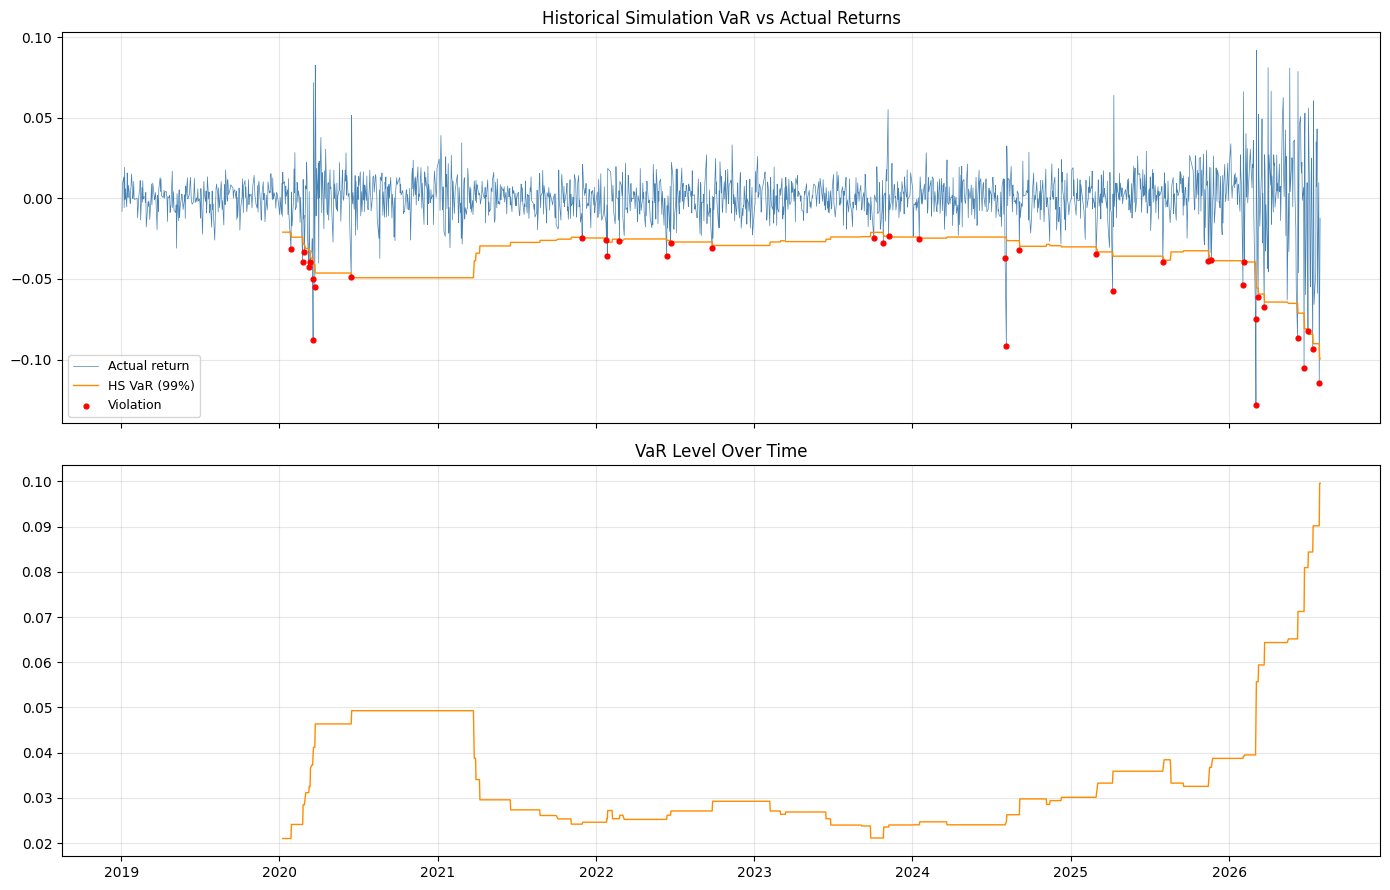

In [3]:
"""Historical Simulation 방식의 VaR 산출 및 위반 판정.

저장소 루트에서 실행한다:
    python codes/02_historical_var.py
"""

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DATA_PATH = "data/kospi_returns.csv"
FIGURE_DIR = "figures"
DATA_DIR = "data"
FIGURE_NAME = "02_historical_var_image.png"
OUTPUT_NAME = "var_historical.csv"

WINDOW = 250
CONFIDENCE_LEVEL = 0.99


def load_returns(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    return df["log_return"]


def historical_var(returns, window=WINDOW, confidence=CONFIDENCE_LEVEL):
    """과거 window일 수익률의 경험적 분위수를 VaR로 사용한다.

    분포를 모수적으로 가정하지 않아 두꺼운 꼬리가 그대로 반영되나,
    표본에 없던 규모의 손실은 반영하지 못한다.

    shift(1)은 look-ahead bias를 차단한다. t시점 VaR은 t-1까지의
    정보만으로 추정되어야 한다.
    """
    alpha = 1 - confidence
    var = returns.rolling(window).quantile(alpha).shift(1)
    return -var


def flag_violations(returns, var):
    """실제 손실이 VaR을 초과한 날을 1로 표시한 hit sequence를 반환한다."""
    valid = var.notna()
    hit = pd.Series(np.nan, index=returns.index)
    hit[valid] = (returns[valid] < -var[valid]).astype(int)
    return hit


def summarize(var, hit):
    n = int(hit.notna().sum())
    n_violations = int(hit.sum())

    print("Historical Simulation VaR")
    print(f"  Window          : {WINDOW} days")
    print(f"  Confidence      : {CONFIDENCE_LEVEL:.0%}")
    print(f"  Testable days   : {n:,}")
    print()
    print(f"  Violations      : {n_violations}")
    print(f"  Expected        : {n * (1 - CONFIDENCE_LEVEL):.1f}")
    print(f"  Violation rate  : {n_violations / n:.4f}")
    print(f"  Expected rate   : {1 - CONFIDENCE_LEVEL:.4f}")
    print()
    print(f"  Mean VaR        : {var.mean():.4f}")
    print(f"  Min VaR         : {var.min():.4f} ({var.idxmin().date()})")
    print(f"  Max VaR         : {var.max():.4f} ({var.idxmax().date()})")
    print()

    dates = hit[hit == 1].index
    if len(dates) > 0:
        by_year = pd.Series(1, index=dates).groupby(dates.year).sum()
        print("  Violations by year")
        for year, count in by_year.items():
            print(f"    {year}: {count:2d}")


def plot_var(returns, var, hit, path):
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(returns.index, returns, linewidth=0.5,
                 color="steelblue", label="Actual return")
    axes[0].plot(var.index, -var, linewidth=1.0,
                 color="darkorange", label=f"HS VaR ({CONFIDENCE_LEVEL:.0%})")

    violations = hit[hit == 1].index
    axes[0].scatter(violations, returns.loc[violations],
                    color="red", s=12, zorder=5, label="Violation")

    axes[0].set_title("Historical Simulation VaR vs Actual Returns")
    axes[0].legend(loc="lower left", fontsize=9)
    axes[0].grid(alpha=0.3)

    # 위기 국면 이후 250일이 경과하면 해당 손실이 추정 윈도우에서
    # 이탈하며 VaR이 계단식으로 하락한다.
    axes[1].plot(var.index, var, linewidth=1.0, color="darkorange")
    axes[1].set_title("VaR Level Over Time")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()


def main():
    os.makedirs(FIGURE_DIR, exist_ok=True)
    os.makedirs(DATA_DIR, exist_ok=True)

    returns = load_returns(DATA_PATH)
    var = historical_var(returns)
    hit = flag_violations(returns, var)

    summarize(var, hit)
    plot_var(returns, var, hit, os.path.join(FIGURE_DIR, FIGURE_NAME))

    result = pd.DataFrame({
        "log_return": returns,
        "var_hs": var,
        "hit_hs": hit,
    })
    result.to_csv(os.path.join(DATA_DIR, OUTPUT_NAME), encoding="utf-8-sig")


if __name__ == "__main__":
    main()

Parametric VaR - Normal
  Testable days   : 1,607
  Violations      : 55
  Expected        : 16.1
  Violation rate  : 0.0342
  Mean VaR        : 0.0296
  Min VaR         : 0.0179 (2020-01-21)
  Max VaR         : 0.0697 (2026-07-30)
  Violations by year
    2020: 14
    2021:  1
    2022:  7
    2023:  3
    2024:  7
    2025:  8
    2026: 15

Parametric VaR - Student-t
  Testable days   : 1,606
  Violations      : 38
  Expected        : 16.1
  Violation rate  : 0.0237
  Mean VaR        : 0.0337
  Min VaR         : 0.0196 (2020-01-21)
  Max VaR         : 0.0797 (2026-07-30)
  Violations by year
    2020: 12
    2022:  4
    2023:  1
    2024:  3
    2025:  6
    2026: 12

Estimated degrees of freedom
  Mean : 4.17
  Range: 4.00 ~ 6.49



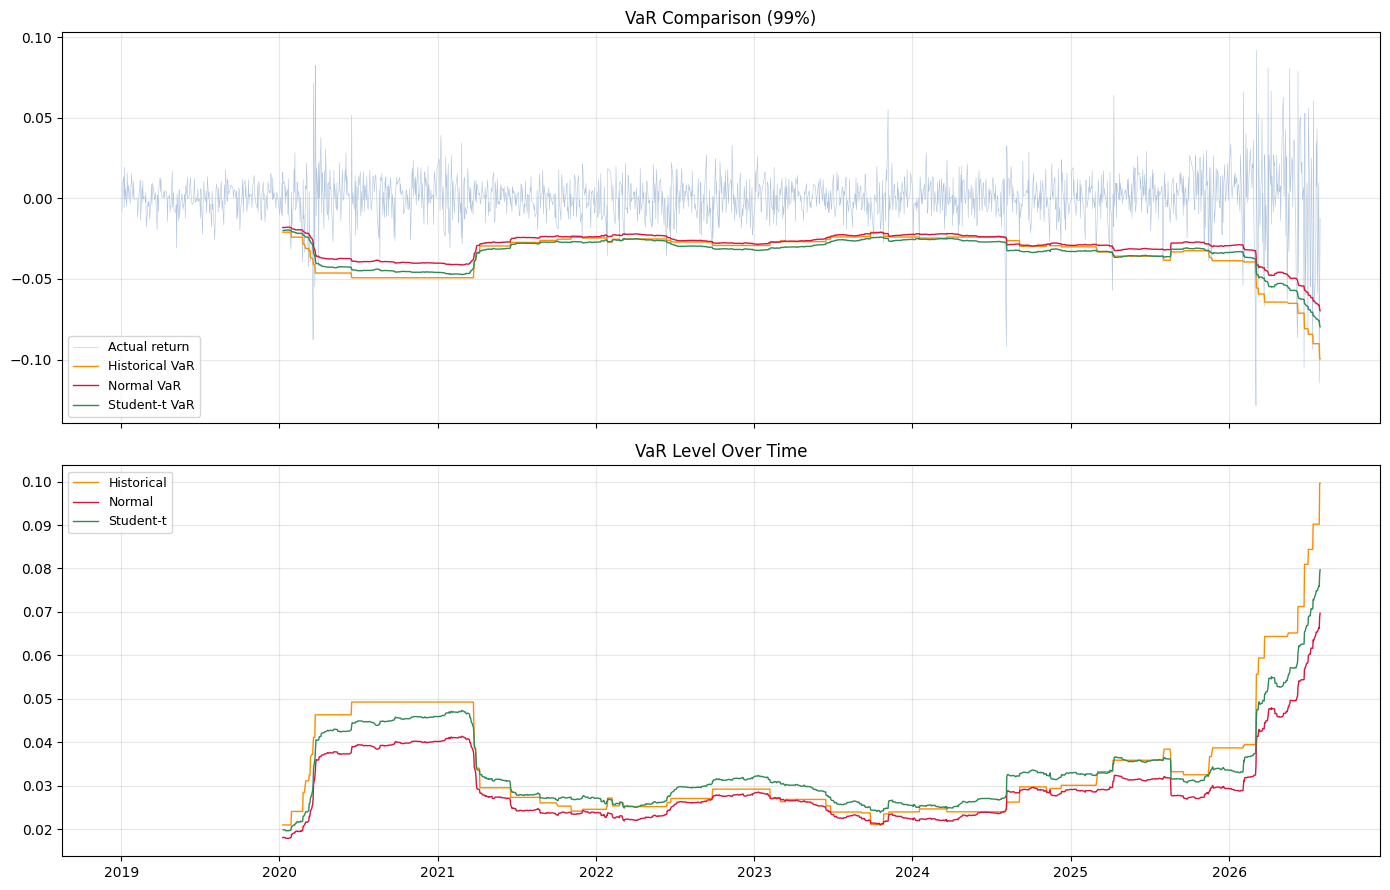

In [6]:
"""Parametric 방식의 VaR 산출: 정규분포 및 Student-t 분포 가정.

저장소 루트에서 실행한다:
    python codes/03_Parametric_VaR.py
"""

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


DATA_PATH = "data/kospi_returns.csv"
HISTORICAL_PATH = "data/var_historical.csv"
FIGURE_DIR = "figures"
DATA_DIR = "data"
FIGURE_NAME = "03_parametric_var_image.png"
OUTPUT_NAME = "var_parametric.csv"

WINDOW = 250
CONFIDENCE_LEVEL = 0.99

UPDATE_FREQ = 20   # 자유도 갱신 주기(거래일)
NU_MIN = 4.0       # 첨도 발산 및 분위수 비단조 구간 차단
NU_MAX = 30.0      # 이 이상은 정규분포와 실질적 차이 없음


def load_returns(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    return df["log_return"]


def parametric_var_normal(returns, window=WINDOW, confidence=CONFIDENCE_LEVEL):
    """정규분포 가정 하의 VaR: -(μ + z·σ), z = -2.326 at 99%.

    shift(1)은 look-ahead bias를 차단한다. t시점 VaR은 t-1까지의
    정보만으로 추정되어야 한다.
    """
    z = stats.norm.ppf(1 - confidence)
    mu = returns.rolling(window).mean().shift(1)
    sigma = returns.rolling(window).std().shift(1)
    return -(mu + z * sigma)


def estimate_degrees_of_freedom(returns, window=WINDOW,
                                update_freq=UPDATE_FREQ,
                                nu_min=NU_MIN, nu_max=NU_MAX):
    """확장 윈도우 최대우도추정으로 t분포 자유도를 추정한다.

    롤링 250일 추정은 표본이 정규분포에 가까운 안정 구간에서 ν가 발산하여
    (수만 단위) 사실상 정규분포로 퇴화한다. 확장 윈도우는 과거 관측치를
    누적하므로 극단값 정보가 유지되어 추정이 안정적이다.

    ν는 꼬리 두께를 결정하는 구조적 모수로 변동성보다 느리게 변하므로
    update_freq 간격으로만 갱신한다.

    [nu_min, nu_max] 클리핑의 근거:
      ν < 4에서는 첨도가 발산하며, 표준화 분위수가 ν에 대해 비단조가 되어
      ν가 작을수록 VaR이 오히려 작아지는 역전이 발생한다.
      ν > 30에서는 정규분포와 실질적 차이가 없다.
    """
    values = returns.to_numpy()
    nu = pd.Series(np.nan, index=returns.index)

    current = np.nan
    for i in range(window, len(values)):
        if (i - window) % update_freq == 0:
            sample = values[:i]
            sample = sample[~np.isnan(sample)]
            current = stats.t.fit(sample)[0]
        nu.iloc[i] = current

    return nu.clip(nu_min, nu_max)


def parametric_var_t(returns, window=WINDOW, confidence=CONFIDENCE_LEVEL):
    """Student-t 분포 가정 하의 VaR.

    자유도 ν인 t분포의 분산은 ν/(ν-2)이므로, σ를 척도로 사용하기 전에
    분산이 1이 되도록 분위수를 표준화한다. 이 보정을 생략하면 변동성이
    이중으로 반영되어 VaR이 과대 산출된다.
    """
    mu = returns.rolling(window).mean().shift(1)
    sigma = returns.rolling(window).std().shift(1)
    nu = estimate_degrees_of_freedom(returns).shift(1)

    t_quantile = stats.t.ppf(1 - confidence, nu)
    t_standardized = t_quantile / np.sqrt(nu / (nu - 2))

    return -(mu + t_standardized * sigma), nu


def flag_violations(returns, var):
    valid = var.notna()
    hit = pd.Series(np.nan, index=returns.index)
    hit[valid] = (returns[valid] < -var[valid]).astype(int)
    return hit


def summarize(name, var, hit):
    n = int(hit.notna().sum())
    x = int(hit.sum())

    print(f"{name}")
    print(f"  Testable days   : {n:,}")
    print(f"  Violations      : {x}")
    print(f"  Expected        : {n * (1 - CONFIDENCE_LEVEL):.1f}")
    print(f"  Violation rate  : {x / n:.4f}")
    print(f"  Mean VaR        : {var.mean():.4f}")
    print(f"  Min VaR         : {var.min():.4f} ({var.idxmin().date()})")
    print(f"  Max VaR         : {var.max():.4f} ({var.idxmax().date()})")

    dates = hit[hit == 1].index
    if len(dates) > 0:
        by_year = pd.Series(1, index=dates).groupby(dates.year).sum()
        print("  Violations by year")
        for year, count in by_year.items():
            print(f"    {year}: {count:2d}")
    print()


def plot_comparison(returns, var_dict, path):
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    colors = {"Historical": "darkorange", "Normal": "crimson", "Student-t": "seagreen"}

    axes[0].plot(returns.index, returns, linewidth=0.4,
                 color="lightsteelblue", label="Actual return")
    for name, var in var_dict.items():
        axes[0].plot(var.index, -var, linewidth=1.0,
                     color=colors.get(name), label=f"{name} VaR")
    axes[0].set_title(f"VaR Comparison ({CONFIDENCE_LEVEL:.0%})")
    axes[0].legend(loc="lower left", fontsize=9)
    axes[0].grid(alpha=0.3)

    for name, var in var_dict.items():
        axes[1].plot(var.index, var, linewidth=1.0,
                     color=colors.get(name), label=name)
    axes[1].set_title("VaR Level Over Time")
    axes[1].legend(loc="upper left", fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()


def main():
    os.makedirs(FIGURE_DIR, exist_ok=True)
    os.makedirs(DATA_DIR, exist_ok=True)

    returns = load_returns(DATA_PATH)

    var_normal = parametric_var_normal(returns)
    hit_normal = flag_violations(returns, var_normal)

    var_t, nu = parametric_var_t(returns)
    hit_t = flag_violations(returns, var_t)

    summarize("Parametric VaR - Normal", var_normal, hit_normal)
    summarize("Parametric VaR - Student-t", var_t, hit_t)

    print("Estimated degrees of freedom")
    print(f"  Mean : {nu.mean():.2f}")
    print(f"  Range: {nu.min():.2f} ~ {nu.max():.2f}")
    print()

    var_dict = {"Normal": var_normal, "Student-t": var_t}
    if os.path.exists(HISTORICAL_PATH):
        historical = pd.read_csv(HISTORICAL_PATH, index_col=0, parse_dates=True)
        var_dict = {"Historical": historical["var_hs"], **var_dict}

    plot_comparison(returns, var_dict, os.path.join(FIGURE_DIR, FIGURE_NAME))

    result = pd.DataFrame({
        "log_return": returns,
        "var_normal": var_normal,
        "hit_normal": hit_normal,
        "var_t": var_t,
        "hit_t": hit_t,
        "nu": nu,
    })
    result.to_csv(os.path.join(DATA_DIR, OUTPUT_NAME), encoding="utf-8-sig")


if __name__ == "__main__":
    main()